EWMA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Kolkata_weather.csv')

In [4]:
df.head()

,Address,Date time,Minimum Temperature,Maximum Temperature,Temperature,Dew Point,Relative Humidity,Heat Index,Wind Speed,Wind Gust,...,Visibility,Cloud Cover,Sea Level Pressure,Weather Type,Latitude,Longitude,Resolved Address,Name,Info,Conditions
0,"Kolkata,West Bengal,India",01/01/2017,14.0,25.3,19.9,16.5,82.47,NaN,5.8,NaN,...,1.2,4.9,1015.9,"Mist, Fog, Smoke Or Haze",22.5705,88.3713,"Kolkata, WB, India","Kolkata, WB, India",NaN,Clear
1,"Kolkata,West Bengal,India",01/02/2017,16.0,26.0,20.6,16.0,76.76,NaN,8.1,NaN,...,1.4,0.3,1015.6,"Mist, Fog, Smoke Or Haze",22.5705,88.3713,"Kolkata, WB, India","Kolkata, WB, India",NaN,Clear
2,"Kolkata,West Bengal,India",01/03/2017,16.0,27.0,21.1,15.6,73.12,27.3,9.2,NaN,...,1.6,10.7,1014.7,"Mist, Smoke Or Haze",22.5705,88.3713,"Kolkata, WB, India","Kolkata, WB, India",NaN,Clear
3,"Kolkata,West Bengal,India",01/04/2017,16.0,25.0,19.9,14.5,72.57,NaN,8.1,NaN,...,1.8,2.3,1014.6,"Mist, Smoke Or Haze",22.5705,88.3713,"Kolkata, WB, India","Kolkata, WB, India",NaN,Clear
4,"Kolkata,West Bengal,India",01/05/2017,15.0,25.6,19.6,13.7,71.88,NaN,8.1,NaN,...,1.9,0.0,1013.7,"Mist, Smoke Or Haze",22.5705,88.3713,"Kolkata, WB, India","Kolkata, WB, India",NaN,Clear


In [7]:
df = df[['Date time', 'Minimum Temperature', 'Maximum Temperature']]

In [8]:
df.head()

,Date time,Minimum Temperature,Maximum Temperature
0,01/01/2017,14.0,25.3
1,01/02/2017,16.0,26.0
2,01/03/2017,16.0,27.0
3,01/04/2017,16.0,25.0
4,01/05/2017,15.0,25.6


In [9]:
df['Date time'] = pd.to_datetime(df['Date time'])

In [10]:
df = df.sort_values('Date time')

In [11]:
df.head()

,Date time,Minimum Temperature,Maximum Temperature
0,2017-01-01,14.0,25.3
1,2017-01-02,16.0,26.0
2,2017-01-03,16.0,27.0
3,2017-01-04,16.0,25.0
4,2017-01-05,15.0,25.6


In [12]:
df.set_index('Date time', inplace=True)

In [13]:
df.head()

,Minimum Temperature,Maximum Temperature
Date time,,
2017-01-01,14.0,25.3
2017-01-02,16.0,26.0
2017-01-03,16.0,27.0
2017-01-04,16.0,25.0
2017-01-05,15.0,25.6


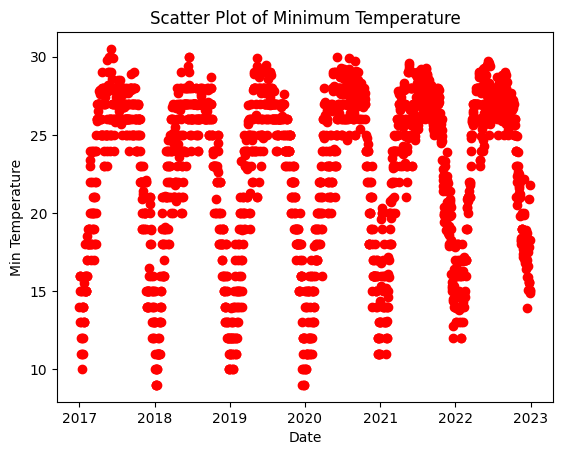

In [16]:
plt.scatter(df.index, df['Minimum Temperature'], color='red')
plt.xlabel("Date")
plt.ylabel("Min Temperature")
plt.title("Scatter Plot of Minimum Temperature")
plt.show()

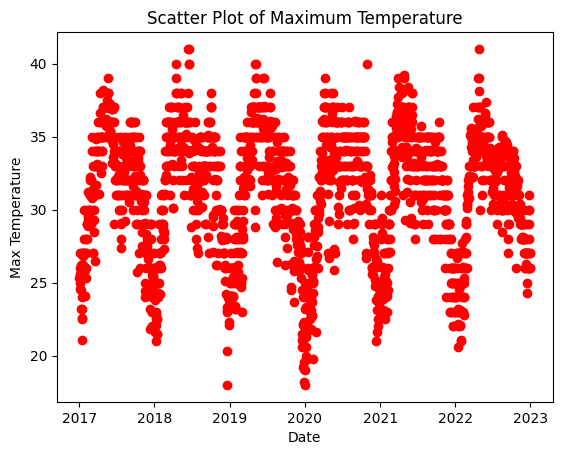

In [17]:
plt.scatter(df.index, df['Maximum Temperature'], color='red')
plt.xlabel("Date")
plt.ylabel("Max Temperature")
plt.title("Scatter Plot of Maximum Temperature")
plt.show()

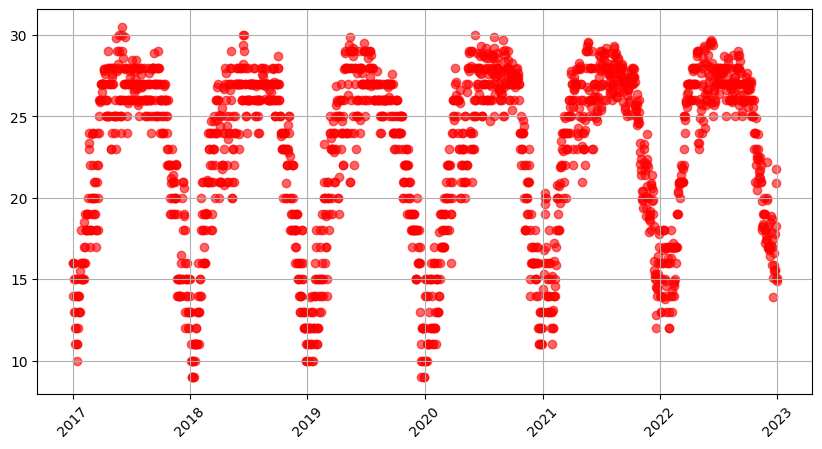

In [18]:
plt.figure(figsize=(10,5))
plt.scatter(df.index, df['Minimum Temperature'], color='red', alpha=0.6)

plt.xticks(rotation=45)
plt.grid()
plt.show()

In [23]:
x1 = df['Minimum Temperature'].ewm(alpha=0.1).mean()

In [24]:
x1

Date time
2017-01-01    14.000000
2017-01-02    15.052632
2017-01-03    15.402214
2017-01-04    15.576040
2017-01-05    15.435374
                ...    
2022-12-27    17.618567
2022-12-28    17.686710
2022-12-29    17.418039
2022-12-30    17.166235
2022-12-31    16.959612
Name: Minimum Temperature, Length: 2191, dtype: float64

In [25]:
df['ewma']=x1
df

,Minimum Temperature,Maximum Temperature,ewma
Date time,,,
2017-01-01,14.0,25.3,14.000000
2017-01-02,16.0,26.0,15.052632
2017-01-03,16.0,27.0,15.402214
2017-01-04,16.0,25.0,15.576040
2017-01-05,15.0,25.6,15.435374
...,...,...,...
2022-12-27,21.8,30.0,17.618567
2022-12-28,18.3,27.0,17.686710
2022-12-29,15.0,26.0,17.418039


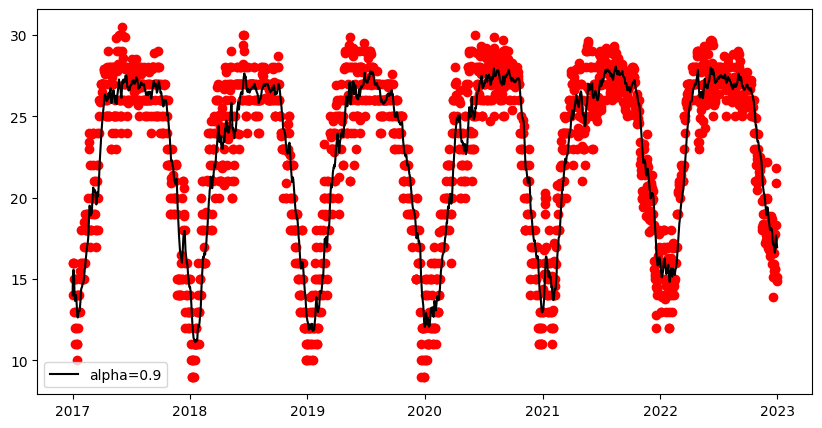

In [26]:
plt.figure(figsize=(10,5))
plt.scatter(df.index, df['Minimum Temperature'], color='red')
plt.plot(df.index, x1, color='black', label='alpha=0.9')
plt.legend()
plt.show()